In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import keras
from keras.layers import Input,Dense,Layer
from keras.models import Model
from keras.datasets import mnist
import tensorflow as tf

In [23]:
batch_size=100
original_dim=284
latent_dim=2
intermediate_dim=256
nb_epoch=5
epsilon_std=1.0

In [24]:
class Sampling(Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [25]:

class Sampling(Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

class VAE(keras.Model):

    def __init__(self, encoder, decoder, original_dim, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.original_dim = original_dim
        self.total_loss_tracker = keras.metrics.Mean(name="loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker
        ]

    def _compute_losses(self, data):
        x = data
        z_mean, z_log_var, z = self.encoder(x, training=True)
        reconstruction = self.decoder(z, training=True)

        recon_loss = self.original_dim * tf.reduce_mean(
            keras.losses.binary_crossentropy(x, reconstruction)
        )

        kl_loss = -0.5 * tf.reduce_sum(
            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=-1
        )
        kl_loss = tf.reduce_mean(kl_loss)
        
        total_loss = recon_loss + kl_loss
        return total_loss, recon_loss, kl_loss


    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        with tf.GradientTape() as tape:
            total_loss, recon_loss, kl_loss = self._compute_losses(data)
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}  
    
    
    
    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        total_loss, recon_loss, kl_loss = self._compute_losses(data)
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

In [26]:

# Decoder
decoder_inputs = Input(shape=(latent_dim,), name="decoder_input")
h_decoded = Dense(intermediate_dim, activation="relu")(decoder_inputs)
x_decoded_mean = Dense(original_dim, activation="sigmoid")(h_decoded)
decoder = Model(decoder_inputs, x_decoded_mean, name="decoder")
decoder.summary()

Model: "decoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 decoder_input (InputLayer)  [(None, 2)]               0         
                                                                 
 dense_14 (Dense)            (None, 256)               768       
                                                                 
 dense_15 (Dense)            (None, 284)               72988     
                                                                 
Total params: 73756 (288.11 KB)
Trainable params: 73756 (288.11 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [27]:
# Encoder
encoder_inputs = Input(shape=(original_dim,), name="encoder_input")
h = Dense(intermediate_dim, activation="relu")(encoder_inputs)
z_mean = Dense(latent_dim, name="z_mean")(h)
z_log_var = Dense(latent_dim, name="z_log_var")(h)
z = Sampling()([z_mean, z_log_var])
encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()

Model: "encoder"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 encoder_input (InputLayer)  [(None, 284)]                0         []                            
                                                                                                  
 dense_16 (Dense)            (None, 256)                  72960     ['encoder_input[0][0]']       
                                                                                                  
 z_mean (Dense)              (None, 2)                    514       ['dense_16[0][0]']            
                                                                                                  
 z_log_var (Dense)           (None, 2)                    514       ['dense_16[0][0]']            
                                                                                            

In [28]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

x_train = x_train.reshape((len(x_train),np.prod(x_train.shape[1:]) ))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)

x_train shape: (60000, 784)
x_test shape: (10000, 784)


Epoch 1/5
600/600 [==============================] - 4s 6ms/step - loss: 160.8957 - reconstruction_loss: 155.6124 - kl_loss: 5.2833 - val_loss: 160.5706 - val_reconstruction_loss: 155.1779 - val_kl_loss: 5.3928
Epoch 2/5
600/600 [==============================] - 4s 6ms/step - loss: 159.5932 - reconstruction_loss: 154.2014 - kl_loss: 5.3918 - val_loss: 159.4039 - val_reconstruction_loss: 154.0327 - val_kl_loss: 5.3712
Epoch 3/5
600/600 [==============================] - 3s 6ms/step - loss: 158.4384 - reconstruction_loss: 152.9572 - kl_loss: 5.4811 - val_loss: 158.3883 - val_reconstruction_loss: 152.7746 - val_kl_loss: 5.6137
Epoch 4/5
600/600 [==============================] - 3s 6ms/step - loss: 157.4594 - reconstruction_loss: 151.8950 - kl_loss: 5.5644 - val_loss: 157.5705 - val_reconstruction_loss: 152.1493 - val_kl_loss: 5.4212
Epoch 5/5
100/100 [==============================] - 0s 934us/step


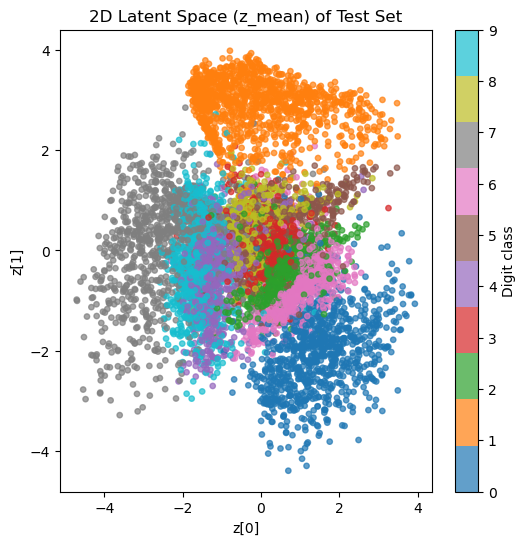

In [14]:
vae = VAE(encoder, decoder, original_dim=flatten_dim)
vae.compile(optimizer='adam')
history = vae.fit(
    x_train,
    x_train,
    epochs=nb_epoch,
    batch_size=batch_size,
    validation_data=(x_test, x_test),
    verbose=1
)

z_mean_model = Model(encoder.input, encoder.output[0])
x_test_encoded = z_mean_model.predict(x_test, batch_size=batch_size)

plt.figure(figsize=(6, 6))
plt.scatter(
    x_test_encoded[:, 0], x_test_encoded[:, 1],
    c=y_test, cmap='tab10', s=15, alpha=0.7
)
plt.colorbar(label="Digit class")
plt.xlabel("z[0]")
plt.ylabel("z[1]")
plt.title("2D Latent Space (z_mean) of Test Set")
plt.show()

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras.layers import Input, Dense, Layer
from keras.models import Model
from keras.datasets import mnist
import tensorflow as tf

batch_size = 100
latent_dim = 2
intermediate_dim = 256
nb_epoch = 5

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

flatten_dim = np.prod(x_train.shape[1:])
x_train = x_train.reshape((len(x_train), flatten_dim))
x_test = x_test.reshape((len(x_test), flatten_dim))

class Sampling(Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

encoder_inputs = Input(shape=(flatten_dim,))
h = Dense(intermediate_dim, activation="relu")(encoder_inputs)
z_mean = Dense(latent_dim)(h)
z_log_var = Dense(latent_dim)(h)
z = Sampling()([z_mean, z_log_var])
encoder = Model(encoder_inputs, [z_mean, z_log_var, z])
encoder.summary()

decoder_inputs = Input(shape=(latent_dim,))
h_decoded = Dense(intermediate_dim, activation="relu")(decoder_inputs)
x_decoded_mean = Dense(flatten_dim, activation="sigmoid")(h_decoded)
decoder = Model(decoder_inputs, x_decoded_mean)
decoder.summary()

class VAE(keras.Model):
    def __init__(self, encoder, decoder, original_dim, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.original_dim = original_dim
        self.total_loss_tracker = keras.metrics.Mean(name="loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")
    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker
        ]
    def _compute_losses(self, data):
        x = data
        z_mean, z_log_var, z = self.encoder(x, training=True)
        reconstruction = self.decoder(z, training=True)
        recon_loss = self.original_dim * tf.reduce_mean(
            keras.losses.binary_crossentropy(x, reconstruction)
        )
        kl_loss = -0.5 * tf.reduce_sum(
            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=-1
        )
        kl_loss = tf.reduce_mean(kl_loss)
        total_loss = recon_loss + kl_loss
        return total_loss, recon_loss, kl_loss
    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        with tf.GradientTape() as tape:
            total_loss, recon_loss, kl_loss = self._compute_losses(data)
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}
    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        total_loss, recon_loss, kl_loss = self._compute_losses(data)
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

vae = VAE(encoder, decoder, original_dim=flatten_dim)
vae.compile(optimizer='adam')
history = vae.fit(
    x_train,
    x_train,
    epochs=nb_epoch,
    batch_size=batch_size,
    validation_data=(x_test, x_test),
    verbose=1
)

z_mean_model = Model(encoder.input, encoder.output[0])
x_test_encoded = z_mean_model.predict(x_test, batch_size=batch_size)

plt.figure(figsize=(6, 6))
plt.scatter(
    x_test_encoded[:, 0], x_test_encoded[:, 1],
    c=y_test, cmap='tab10', s=15, alpha=0.7
)
plt.colorbar(label="Digit class")
plt.xlabel("z[0]")
plt.ylabel("z[1]")
plt.title("2D Latent Space (z_mean) of Test Set")
plt.show()import numpy as np
import matplotlib.pyplot as plt
import keras
from keras.layers import Input, Dense, Layer
from keras.models import Model
from keras.datasets import mnist
import tensorflow as tf

batch_size = 100
latent_dim = 2
intermediate_dim = 256
nb_epoch = 5

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

flatten_dim = np.prod(x_train.shape[1:])
x_train = x_train.reshape((len(x_train), flatten_dim))
x_test = x_test.reshape((len(x_test), flatten_dim))

class Sampling(Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

encoder_inputs = Input(shape=(flatten_dim,))
h = Dense(intermediate_dim, activation="relu")(encoder_inputs)
z_mean = Dense(latent_dim)(h)
z_log_var = Dense(latent_dim)(h)
z = Sampling()([z_mean, z_log_var])
encoder = Model(encoder_inputs, [z_mean, z_log_var, z])
encoder.summary()

decoder_inputs = Input(shape=(latent_dim,))
h_decoded = Dense(intermediate_dim, activation="relu")(decoder_inputs)
x_decoded_mean = Dense(flatten_dim, activation="sigmoid")(h_decoded)
decoder = Model(decoder_inputs, x_decoded_mean)
decoder.summary()

class VAE(keras.Model):
    def __init__(self, encoder, decoder, original_dim, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.original_dim = original_dim
        self.total_loss_tracker = keras.metrics.Mean(name="loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")
    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker
        ]
    def _compute_losses(self, data):
        x = data
        z_mean, z_log_var, z = self.encoder(x, training=True)
        reconstruction = self.decoder(z, training=True)
        recon_loss = self.original_dim * tf.reduce_mean(
            keras.losses.binary_crossentropy(x, reconstruction)
        )
        kl_loss = -0.5 * tf.reduce_sum(
            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=-1
        )
        kl_loss = tf.reduce_mean(kl_loss)
        total_loss = recon_loss + kl_loss
        return total_loss, recon_loss, kl_loss
    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        with tf.GradientTape() as tape:
            total_loss, recon_loss, kl_loss = self._compute_losses(data)
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}
    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        total_loss, recon_loss, kl_loss = self._compute_losses(data)
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

vae = VAE(encoder, decoder, original_dim=flatten_dim)
vae.compile(optimizer='adam')
history = vae.fit(
    x_train,
    x_train,
    epochs=nb_epoch,
    batch_size=batch_size,
    validation_data=(x_test, x_test),
    verbose=1
)

z_mean_model = Model(encoder.input, encoder.output[0])
x_test_encoded = z_mean_model.predict(x_test, batch_size=batch_size)

plt.figure(figsize=(6, 6))
plt.scatter(
    x_test_encoded[:, 0], x_test_encoded[:, 1],
    c=y_test, cmap='tab10', s=15, alpha=0.7
)
plt.colorbar(label="Digit class")
plt.xlabel("z[0]")
plt.ylabel("z[1]")
plt.title("2D Latent Space (z_mean) of Test Set")
plt.show()

SyntaxError: invalid syntax (2665623672.py, line 116)